<a href="https://colab.research.google.com/github/Faisalmalik01/deeplearning/blob/main/performance_Matrices.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Importing Necessary Libraries

This cell imports all the required Python libraries for our analysis.
- `matplotlib.pyplot` is used for plotting and visualization.
- `sklearn.metrics` provides functions to evaluate classification models, such as `confusion_matrix` and `classification_report`.
- `numpy` is fundamental for numerical operations, especially with arrays.
- `pandas` is used for data manipulation and analysis, particularly for creating DataFrames.
- `seaborn` is a statistical data visualization library based on matplotlib, used here for creating heatmaps.

In [15]:
from matplotlib import pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import pandas as pd
import seaborn as sns

### Defining `print_confusion_matrix` Function

This cell defines a utility function `print_confusion_matrix` which takes a confusion matrix, class names, and optional figure size and font size parameters. It then visualizes the confusion matrix as a heatmap using `seaborn`. This function is particularly useful for a clear and intuitive representation of model performance for classification tasks.

In [16]:
def print_confusion_matrix(confusion_matrix, class_names, figsize = (10,7), fontsize=14):
    """Prints a confusion matrix, as returned by sklearn.metrics.confusion_matrix, as a heatmap.

    Note that due to returning the created figure object, when this funciton is called in a
    notebook the figure willl be printed twice. To prevent this, either append ; to your
    function call, or modify the function by commenting out the return expression.

    Arguments
    ---------
    confusion_matrix: numpy.ndarray
        The numpy.ndarray object returned from a call to sklearn.metrics.confusion_matrix.
        Similarly constructed ndarrays can also be used.
    class_names: list
        An ordered list of class names, in the order they index the given confusion matrix.
    figsize: tuple
        A 2-long tuple, the first value determining the horizontal size of the ouputted figure,
        the second determining the vertical size. Defaults to (10,7).
    fontsize: int
        Font size for axes labels. Defaults to 14.

    Returns
    -------
    matplotlib.figure.Figure
        The resulting confusion matrix figure
    """
    df_cm = pd.DataFrame(
        confusion_matrix, index=class_names, columns=class_names,
    )
    fig = plt.figure(figsize=figsize)
    try:
        heatmap = sns.heatmap(df_cm, annot=True, fmt="d")
    except ValueError:
        raise ValueError("Confusion matrix values must be integers.")
    heatmap.yaxis.set_ticklabels(heatmap.yaxis.get_ticklabels(), rotation=0, ha='right', fontsize=fontsize)
    heatmap.xaxis.set_ticklabels(heatmap.xaxis.get_ticklabels(), rotation=45, ha='right', fontsize=fontsize)
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    # Note that due to returning the created figure object, when this funciton is called in a notebook
    # the figure willl be printed twice. To prevent this, either append ; to your function call, or
    # modify the function by commenting out this return expression.
    return fig

### Preparing Sample Data: True vs. Predicted Labels

Here, we define two lists: `truth` and `prediction`.
- `truth` represents the actual labels for a set of samples.
- `prediction` represents the labels predicted by a hypothetical classification model for the same samples.

These lists will be used to calculate and visualize the confusion matrix and classification report.

In [17]:
truth = ["Dog", "Not a Dog", "Dog", "Dog", "Dog", "Not a Dog","Not a Dog", "Dog", "Dog", "Not a Dog" ]
prediction = ["Dog", "Dog", "Dog", "Not a Dog", "Dog", "Not a Dog","Dog",  "Not a Dog", "Dog", "Dog"]

### Calculating and Visualizing the Confusion Matrix

In this cell:
1. We calculate the `confusion_matrix` using `sklearn.metrics.confusion_matrix` by comparing the `truth` and `prediction` lists.
2. We then call our custom `print_confusion_matrix` function to display this matrix as a heatmap. The `class_names` argument ensures that the labels ('Dog', 'Not a Dog') are correctly displayed on the heatmap's axes, making it easy to interpret true positives, true negatives, false positives, and false negatives.

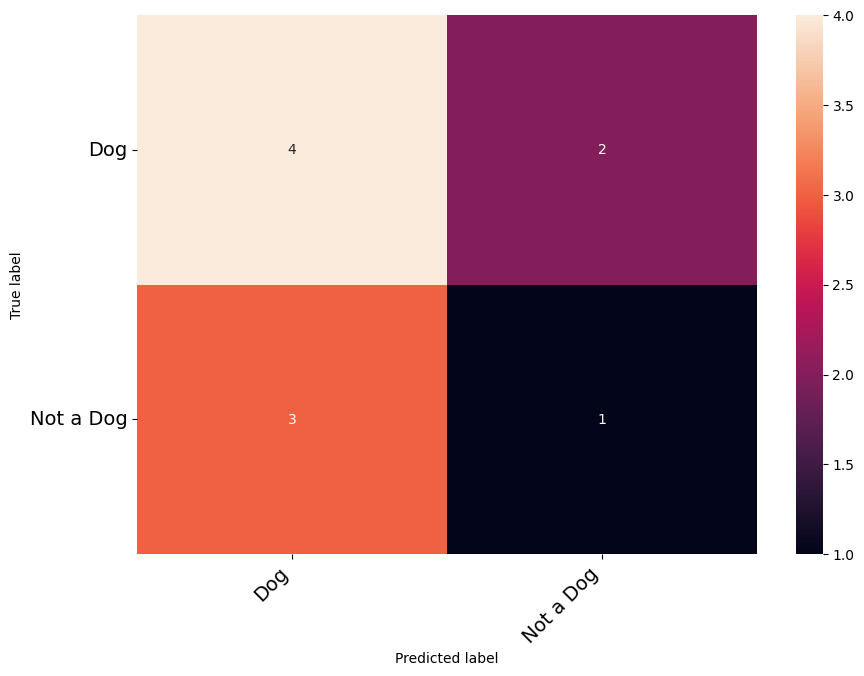

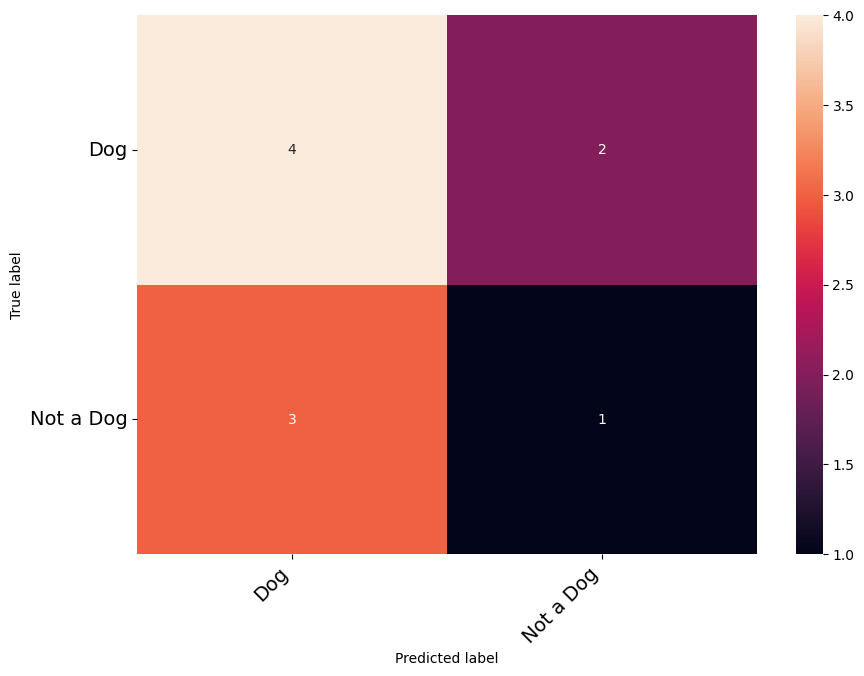

In [18]:
cm = confusion_matrix(truth, prediction)
print_confusion_matrix(cm,["Dog", "Not a Dog"])

### Generating the Classification Report

This cell utilizes `sklearn.metrics.classification_report` to generate a text summary of the precision, recall, F1-score, and support for each class ('Dog' and 'Not a Dog'). It also includes overall accuracy, macro average, and weighted average. This report provides a comprehensive view of the model's performance beyond just the confusion matrix.

In [19]:
print(classification_report(truth, prediction))

              precision    recall  f1-score   support

         Dog       0.57      0.67      0.62         6
   Not a Dog       0.33      0.25      0.29         4

    accuracy                           0.50        10
   macro avg       0.45      0.46      0.45        10
weighted avg       0.48      0.50      0.48        10



### Calculating F1-score for 'Dog' Class Manually

This cell demonstrates the manual calculation of the F1-score for the 'Dog' class using the precision (0.57) and recall (0.67) values obtained from the classification report. The F1-score is the harmonic mean of precision and recall, providing a single metric that balances both.

In [21]:
# F1 score for Dog class
2*(0.57*0.67/(0.57+0.67))

0.6159677419354839

### Calculating F1-score for 'Not a Dog' Class Manually

Similar to the previous cell, this calculates the F1-score for the 'Not a Dog' class using its respective precision (0.33) and recall (0.25) values from the classification report. This further illustrates how F1-score is derived and its value for assessing performance on a per-class basis.

In [22]:
# F1 score for Not a Dog class
2*(0.33*0.25)/(0.33+0.25)

0.2844827586206896